<a href="https://colab.research.google.com/github/margheritabenigni/DATASET-2-CHIMICA-Legami-e-Tavola-Periodica-/blob/main/regressione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression   # per il metodo semplice
from scipy import stats
import io
df = pd.read_csv(io.BytesIO(uploaded['batteri.csv']),delimiter=";")
print(df)


    temperatura  tempo   ph  nutrienti  crescitabatterica
0            25     12  7.0        5.0               0.45
1            30     12  7.0        5.0               0.60
2            35     12  7.0        5.0               0.82
3            40     12  7.0        5.0               0.78
4            25     24  7.0        5.0               0.70
5            30     24  7.0        5.0               0.95
6            35     24  7.0        5.0               1.20
7            40     24  7.0        5.0               1.05
8            25     12  6.5        7.0               0.50
9            30     12  6.5        7.0               0.68
10           35     12  6.5        7.0               0.90
11           40     12  6.5        7.0               0.85
12           25     24  6.5        7.0               0.78
13           30     24  6.5        7.0               1.05
14           35     24  6.5        7.0               1.30
15           40     24  6.5        7.0               1.18
16           2

In [ ]:
print (df['temperatura'])

0     25
1     30
2     35
3     40
4     25
5     30
6     35
7     40
8     25
9     30
10    35
11    40
12    25
13    30
14    35
15    40
16    25
17    30
18    35
19    40
20    25
21    30
22    35
23    40
24    28
25    32
26    36
27    38
28    29
29    34
30    34
Name: temperatura, dtype: int64


=== REGRESSIONE SEMPLICE ===
Intercetta (b0): -0.0303
Coefficiente Temperatura (b1): 0.0274
R²: 0.3542


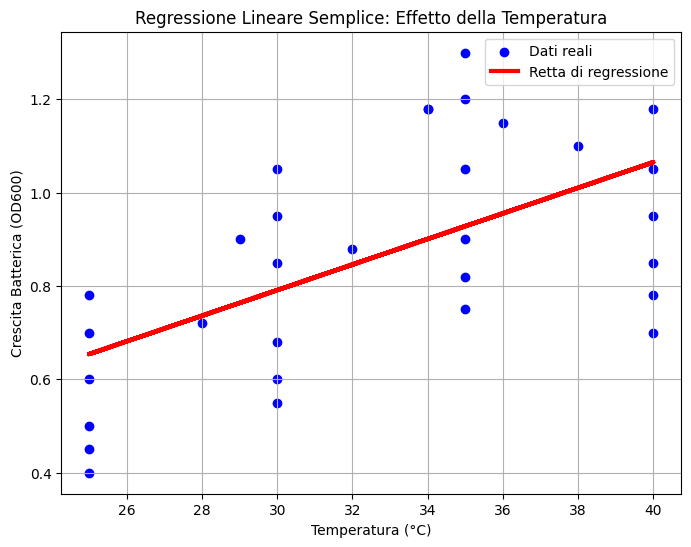

In [ ]:
import statsmodels.api as sm

# Prepariamo X (variabile indipendente) e y (variabile dipendente)
X = df[['temperatura']]   # doppia parentesi quadra perché è una colonna
y = df['crescitabatterica']

# Creiamo il modello
model = LinearRegression()
model.fit(X, y)

# Risultati
print("=== REGRESSIONE SEMPLICE ===")
print(f"Intercetta (b0): {model.intercept_:.4f}")
print(f"Coefficiente Temperatura (b1): {model.coef_[0]:.4f}")
print(f"R²: {model.score(X, y):.4f}")   # quanto il modello spiega i dati

# Grafico
plt.figure(figsize=(8,6))
plt.scatter(df['temperatura'], df['crescitabatterica'], color='blue', label='Dati reali')
plt.plot(df['temperatura'], model.predict(X), color='red', linewidth=3, label='Retta di regressione')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Crescita Batterica (OD600)')
plt.title('Regressione Lineare Semplice: Effetto della Temperatura')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_multi = df[['temperatura', 'tempo', 'ph', 'nutrienti']]
y = df['crescitabatterica']

# Modello con sklearn (facile)
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\n=== REGRESSIONE MULTIPLA ===")
print("Coefficienti:")
for nome, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  {nome}: {coef:.4f}")
print(f"Intercetta: {model_multi.intercept_:.4f}")
print(f"R²: {model_multi.score(X_multi, y):.4f}")


=== REGRESSIONE MULTIPLA ===
Coefficienti:
  temperatura: 0.0269
  tempo: 0.0261
  ph: 0.4279
  nutrienti: 0.1532
Intercetta: -4.2847
R²: 0.8589


In [ ]:
# ==================== AGGIUNGIAMO LA COLONNA BINARIA ====================
df['altanutrizione'] = (df['nutrienti'] >= 6).astype(int)
print(df)


    temperatura  tempo   ph  nutrienti  crescitabatterica  altanutrizione
0            25     12  7.0        5.0               0.45               0
1            30     12  7.0        5.0               0.60               0
2            35     12  7.0        5.0               0.82               0
3            40     12  7.0        5.0               0.78               0
4            25     24  7.0        5.0               0.70               0
5            30     24  7.0        5.0               0.95               0
6            35     24  7.0        5.0               1.20               0
7            40     24  7.0        5.0               1.05               0
8            25     12  6.5        7.0               0.50               1
9            30     12  6.5        7.0               0.68               1
10           35     12  6.5        7.0               0.90               1
11           40     12  6.5        7.0               0.85               1
12           25     24  6.5        7.0

In [ ]:
print("Distribuzione dei gruppi:")
print(df['altanutrizione'].value_counts())
print("\nMedia crescita per gruppo:")
print(df.groupby('altanutrizione')['crescitabatterica'].mean().round(3))

/tmp/ipykernel_4922/2065275018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='altanutrizione', y='crescitabatterica', data=df, palette=['lightblue', 'lightgreen'])


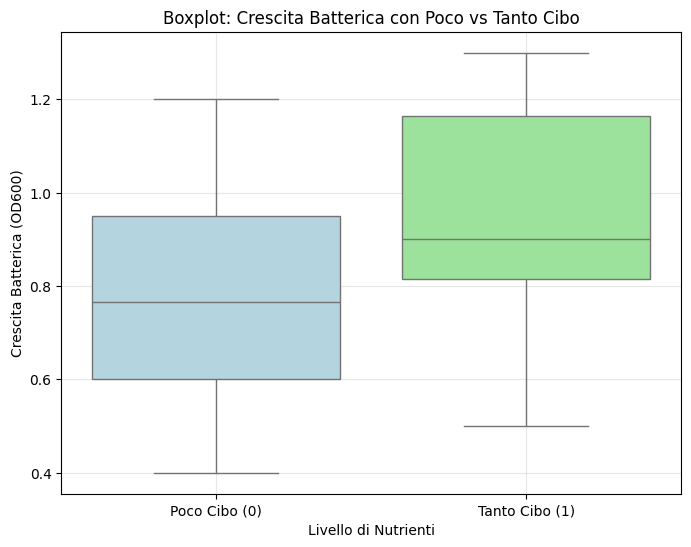

In [ ]:
# ==================== BOXPLOT ====================
plt.figure(figsize=(8, 6))
sns.boxplot(x='altanutrizione', y='crescitabatterica', data=df, palette=['lightblue', 'lightgreen'])
plt.xticks([0, 1], ['Poco Cibo (0)', 'Tanto Cibo (1)'])
plt.title('Boxplot: Crescita Batterica con Poco vs Tanto Cibo')
plt.ylabel('Crescita Batterica (OD600)')
plt.xlabel('Livello di Nutrienti')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ==================== T-TEST ====================
gruppo0 = df[df['altanutrizione'] == 0]['crescitabatterica']
gruppo1 = df[df['altanutrizione'] == 1]['crescitabatterica']

t_stat, p_value = stats.ttest_ind(gruppo0, gruppo1)

print("=== RISULTATI T-TEST ===")
print(f"Media Poco Cibo  : {gruppo0.mean():.3f}")
print(f"Media Tanto Cibo : {gruppo1.mean():.3f}")
print(f"t-statistic      : {t_stat:.3f}")
print(f"p-value          : {p_value:.5f}")

if p_value < 0.05:
    print("→ Differenza statisticamente SIGNIFICATIVA!")
else:
    print("→ Differenza NON significativa")